# An analysis of the propensity of Large Language Models to generate programs with software vulnerabilities
*Probabilistic Programming 2026 Exam by Raúl Pardo ([raup@itu.dk](mailto:raup@itu.dk)) and Andrzej Wąsowski ([wasowski@itu.dk](mailto:wasowski@itu.dk))*<br/>
*version 1.0.1 2026-04-22 12:00*


Software vulnerabilities such as buffer overflows, arithmetic overflows or dereferences pose important risks in software applications.
Attackers exploit this type of vulnerabilities to, e.g., leak sensitive data or perform Denial of Service (DoS) attacks.
Unfortunately, software vulnerabilities are not rare in existing code bases, which, in turn, are used to train LLMs.

In this exam, your task is to explore the following question: Do LLMs generate code with software vulnerabilities?
To this end, you will study a recent dataset of C programs generated by several LLMs [1].
To determine whether the code contains vulnerabilities, the generated programs were analyzed using formal verification.
Given the dangers of shipping code with software vulnerabilities, it is of upmost importance to understand whether LLMs are prone to include these vulnerabilities and what factors make it more likely to generate programs with vulnerabilities.
For instance, are all LLMs (GPT, Gemini, Llama, Mistral, etc.) equally likely to include vulnerabilities?
In human-written programs, the number of lines of code is a good predictor of the probability of having errors in a program; the more lines of code the more likely it is to contain errors.
Is this relation between lines of code and probability of error also present in LLM generated code?
The analysis that you will carry out in this exam will allow you to answer this type of questions.

[1] - Norbert Tihanyi, Tamas Bisztray, Mohamed Amine Ferrag, Ridhi Jain, Lucas C. Cordeiro. How secure is AI-generated code: a large-scale comparison of large language models. In Journal of Empirical Software Engineering (EMSE). 2025.

## Data

The dataset contains a sample of $N = 1766$ LLM generated C programs from the original dataset published in [1].
The dataset is in the file [dataset.csv](dataset.csv). 
Each row in the dataset corresponds to a different C program.
The column *C file name* contains the name of the file containing the generated C program. 
This name is an identifier for the row.
The variables in the dataset are:

* **Category** - This variable specifies whether the program contains a vulnerability or not: `VULNERABLE` and `NON-VULNERABLE`, respectively. Additionally, it also specifies whether the generated program resulted in a parsing error and whether verification timed out before it could determine the presence of vulnerabilities.

<div style="margin-top: 1mm"></div>

* **Error type** - This variable specifies the type of vulnerability found in the program. There are 29 different type of vulnerabilities included in the dataset.

<div style="margin-top: 1mm"></div>

* **LLM name** - This variable reports the name of the LLM that generated the program.

<div style="margin-top: 1mm"></div>

* **Number of parameters** - This variable contains the number of parameters (in billions) of the LLM used to generate the program. For some LLMs, the number of parameters have not been publicly announced. In these cases, the variable is unspecified.
    * Note that for each LLM name the number of parameters is always the same.

<div style="margin-top: 1mm"></div>

* **Number of lines of code** - This variable reports the number of lines of code of the generated program.

<div style="margin-top: 1mm"></div>

* **Cyclomatic complexity** - This variable reports the cyclomatic complexity of the generated program. Cyclomatic complexity is a well established software quality metric that attempts to measure the maintainability and complexity of code. It measures the amount of decision logic in a program. For instance, the more control flow structures such as `if`, `while` or `switch` statements, the higher the cyclomatic complexity.

<div style="margin-top: 1mm"></div>

## Hypotheses

To analyze the propensity of LLMs to generate code with vulnerabilities, you must investigate the following hypotheses:

* **H1** - The LLM `llama2` is less likely to produce programs with vulnerabilities than any other LLM in the dataset.

* **H2** - Larger values of cyclomatic complexity are associated to larger number of lines of code for all LLMs.

* **H3** - A larger number of lines of code increases the probability of observing each vulnerability type.

Your task is to use Bayesian Inference and Regression to decide whether these hypotheses hold, or possibly reject them. This includes:

* Loading, restructuring and transforming the data as needed.

* Designing Bayesian regression models and using the inference algorithms to test the above hypotheses in PyMC.

* Explaining your model idea in English, preferably using a figure, and showing the Python code.

* Checking and reflecting (in writing) on the quality of the sampling process, considering warnings from the tool, sampling summary statistics, trace plots, and autocorrelation plots. Comment whether the quality is good, and whether you had to make any adjustments during the modeling.

* Visualizing the posterior information appropriately to address each of the hypotheses.
  

You should hand in a zip file with a Jupyter notebook and the data file (so that we can run it), and a **PDF file rendering of the Jupyter notebook**, so that your work can be assessed just by reading this file. It appears that the best PDF rendering is obtained by File / Export to HTML, and then saving/printing to PDF from your browser.

Make sure the notebook is actually a **report** readable to the examiners, especially to the censor, who has not been following the course. The report should include:
* A brief introduction.
* Explanations on how data is loaded and cleaned.
* Explanations on analysis and model design (for each of the models you consider).
* A discussion of sampling quality (for each model), all posterior plots that you present, and reflection/decision outcome for each hypothesis.
* An overall conclusion.

**IMPORTANT:** For the tasks below, your code must accompany an explanation of its meaning and intended purpose. **Source code alone is not self-explanatory**. As mentioned above, you should also reflect on the results you get, e.g., highlighting issues with the data, or issues, pitfalls and assumptions of a model. **Exams containing only source code or very scarce explanations will result in low grades, including failing grades.**

The members of the group must be the only authors of the report.

**Use of Generative AI Guidelines:** If you use generative AI for the report (i.e., the written part of your examination), you must adhere to ITU guidelines for the use of generative AI (https://itustudent.itu.dk/Study-Administration/Generative-AI). **This requires adding a section in which you declare how you used generative AI.** You must ensure that your exam submission reflects your own understanding and work. You are fully responsible for and must be able to explain all the content of your submission. The use of generative AI during oral examinations is not permitted.

## Minimum requirements 

1. Design a regression model to predict the probability of generating a program classified as `VULNERABLE` using LLM as a predictor.
  
2. Analyze hypothesis H1 using the regression model in (1.).

## Ideas for extension

**Groups aiming at grade 7 and more should complete the following tasks:**
    
3. Analyze hypothesis H2.
        
4. Perform prior predictive checks in all your models. Explain why the priors you selected are appropriate.
    
5. Perform posterior predictive checks in all your models. Discuss the results in the posterior predictive checks.
    
6. Discuss trace convergence in all your models.
    
**Groups aiming at grade 10 and higher should try 3-5 ideas from below or add some of your own:**

7. Analyze hypothesis H3.
    * Consider plotting posterior predictions with different values of number of lines of code to evaluate this hypothesis.

<div style="margin-top: 1mm"></div>

8. Analyze whether number of lines of code has an impact on cyclomatic complexity.
    
9. Analyze whether number of lines of code (`LOC`) and cyclomatic complexity (`CC`) are confounding variables when used to predict the probability of generating programs with vulnerabilities (`VUL`). That is, determine whether any of these causal graphs are plausible:

```
Option 1
+---+                     +--+
|LOC| ------------------> |CC|
+---+                     +--+
  |                        |  
  |          +---+         |  
  +--------> |VUL| <-------+  
             +---+            

Option 2
+---+                     +--+
|LOC| <------------------ |CC|
+---+                     +--+
  |                        |  
  |          +---+         |  
  +--------> |VUL| <-------+  
             +---+         

Option 3
+---+                     +--+
|LOC|                     |CC|
+---+                     +--+
  |                        |  
  |          +---+         |  
  +--------> |VUL| <-------+  
             +---+         
```

10. Consider mixture models for analyzing the hypotheses above. Explain why the mixture models you evaluate are appropriate in the context of this analysis.
    
11. Design a meaningful multilevel model in the context of these data.
   
12. Use causal reasoning to analyze causal relations between the variables in the dataset; for causal relations not analyzed in (9.).

---

# **Exam Report - Group CaMaMa**

## **Introduction**
This report examines software vulnerabilities in code generated by Large Language Models (LLMs). Attackers can utilize software vulnerabilities for a variety of things such as gaining access to sensitive data and disrupting and shutting down services. As the percentage of code that LLMs produce 

In [18]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"] = True # to for tight_layout()

In [19]:
df = pd.read_csv('dataset.csv')

In [20]:
df.llm_name.unique()

<StringArray>
[    'llama2', 'gemini_pro',      'gpt35',     'falcon',      'gemma',
    'falcon2', 'gpt4o_mini',    'mistral',  'codellama']
Length: 9, dtype: str

In [21]:
print(df['llm_name'].drop_duplicates().reset_index(drop=True))


0        llama2
1    gemini_pro
2         gpt35
3        falcon
4         gemma
5       falcon2
6    gpt4o_mini
7       mistral
8     codellama
Name: llm_name, dtype: str


From the project description we know that there are more categories than just VULNERABLE and NON-VULNERABLE. Therefore we first list all unique categories that are present in the data.

In [22]:
print(df['category'].unique())

<StringArray>
['VULNERABLE', 'NON-VULNERABLE', 'UNKNOWN (time out)', 'PARSING ERROR']
Length: 4, dtype: str


### Cleaning the data
To analyze ***H1** - The LLM `llama2` is less likely to produce programs with vulnerabilities than any other LLM in the dataset*, we want to look at data that is labeled VULNERABLE or NON-VULNERABLE. The current dataset also contains entries instead labeled with PARSING ERROR or UNKNOWN (time out). So we made a comparison where we compare the LLM's with all categories, to only the data with the categories VULNERABLE or NON-VULNERABLE. This is done to ensure that we still have a meaningful amount of data for each LLM, i.e. we are not removing a significant amount of data for each LLM.

In [23]:
# Get an overview of how many entries each model has before cleaning
before_cleaning = df.groupby('llm_name').size()

# Only take the entries where code is labeled vulnerable or non-vulnerable
cleaned_df = df[df['category'].isin(['VULNERABLE', 'NON-VULNERABLE'])]
after_cleaning = cleaned_df.groupby('llm_name').size()

summary_table = pd.concat([before_cleaning, after_cleaning], axis=1)
summary_table.columns = ['Total Entries (Before)', 'Analyzable (After)']
print(summary_table.sort_values(by='Total Entries (Before)', ascending=False))


            Total Entries (Before)  Analyzable (After)
llm_name                                              
gpt35                          474                 433
falcon                         324                 277
gemini_pro                     256                 231
gemma                          236                 214
gpt4o_mini                     197                 166
llama2                          95                  78
falcon2                         73                  67
codellama                       57                  49
mistral                         54                  50


We have now removed all instances of the C code that was not deemed VULNERABLE or NON-VULNERABLE. 
As can be seen by the table above, there is still C code left to analyze, and therefore we continue our analysis.

### Choice of model
* The goal is to design a regression model, that can predict the probability that a LLM makes code that is VULNERABLE.

Whether a program generated by a model is deemed vulnerable or not, is a binary outcome, ie. there is only 2 options. We want to measure the number of successes (i.e. the code is vulnerable), in the fixed amount of generated files from each LLM.
Therefore we assume a binomial model.

### Designing the model

* We first try a single-level model. This model we define as:

\begin{align*}
MV_i &\sim \mathrm{Binomial}(N_i,p_i) & \quad [\,\text{Likelihood}\,] \\
\mathrm{logit}(p_i) &= \alpha_{\mathrm{LLM}[i]}& \quad [\,\text{linear predictor}\,] \\
\alpha_j &\sim \mathrm{Normal}(0.4,1.5) & \quad [\,\text{prior}\,]
\end{align*}



$i$ is the index of the row representing a specific LLM in the dataset, and $MV_i$ is the observed count of VULNERABLE files, while $N_i$ is the total number of generated C code (that is VULNERABLE or NON-VULNERABLE) for a specific index $i$ of the LLM's. 

In addtition to this $p_i$ is the estimated probability that LLM $i$ generates vulnerable code. This probability is derived from our linear predictor  $\alpha_{LLM[i]}$, which represents the specific *intercept* for that LLM. These intercepts are informed by the prior distribution $\alpha_j \sim \text{Normal}(0.4, 1.5)$."

#### Choice of prior
LLM's are blackbox, therefore we cannot be 100% sure on what exactly lies behind the idea of the code they have generated, however we know that they are *usually* trained on data and code from the internet. The problem with this lies in the fact that much C code from the internet is very prone to Vulnerabilities:

"[...] C accounts for a disproportionately high share — often around 40–50% [...] — of reported open source security vulnerabilities." [SOURCE](https://www.securityjourney.com/post/which-programming-language-has-the-most-vulnerabilities) 

In addition to this, all group members have experience coding in C and have experienced the incababilities of these to write C code. In addition to this, from our knowledge of these LLM's that have been tested, some are specialised for certain tasks, such as coding (Code Llama), where as other LLM's are more general capability LLM's (Llama 2), suited for a greater variety of tasks. This could mean that there is a greater variance of the LLM's tendency to produce vulnerable code. 

However we know that LLM's in general are generally still evolving, and might have gotten better than our experiences.

So while we want to choose a prior that reflects our experience, we want to be somewhat conservative and choose a flatter prior.

Therefore, we have picked a prior that is relatively flat, to account for the variance that the different LLM's could have, while still not giving much weight to the extremes.

We go with the prior $\alpha_j \sim \mathrm{Normal}(0.4,1.5)$ which centers the distribution around a belief of 60%.

### Creating the model
We want to collect our data, so we can do an aggregrated binomial regression. This means that we want to group all entries in the dataset together by LLM, such that we get a new dataframe that contains one entry per LLM which will contain the total amount of generated programs for that LLM and the sum of the vulnerable programs for that LLM. 

In [24]:
grouped_df = cleaned_df.groupby('llm_name')['category'].agg(
    Total_Programs='count',
    Vulnerabilities=lambda x: (x == 'VULNERABLE').sum()
).reset_index()

With this we can create the model:

In [25]:
with pm.Model() as m_llm_vulnerable:
    α   = pm.Normal('α',mu=0.4,sigma=1.5,shape=grouped_df.shape[0])
    p   = pm.Deterministic('p',pm.math.invlogit(α))
    
    obs = pm.Binomial('obs',n=grouped_df.Total_Programs,p=p,observed=grouped_df.Vulnerabilities)



Below is a visualization of our model:

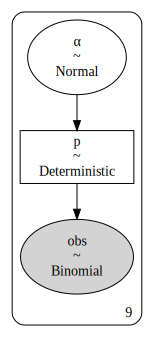

In [26]:
pm.model_to_graphviz(m_llm_vulnerable)

In [35]:
prior_check = pm.sample_prior_predictive(model=m_llm_vulnerable, samples=1000, random_seed=42)

Sampling: [obs, α]


In [36]:
prior_check

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [ ]:
prior_p = prior_check.prior['p']
prior_obs = prior_check.prior_predictive['obs']

Text(0, 0.5, 'Density')

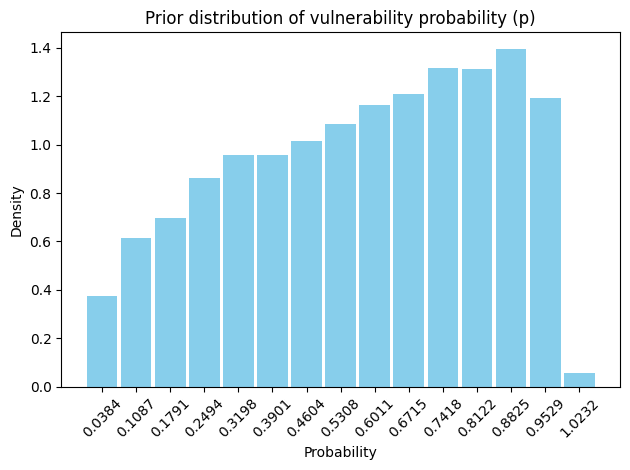

In [46]:
az.plot_dist(prior_p, kind='hist', color='skyblue')
plt.title("Prior distribution of vulnerability probability (p)")
plt.xticks(rotation=45)
plt.xlabel("Probability")
plt.ylabel("Density")


In [27]:
trace_13_2 = pm.sample(model=m_llm_vulnerable,return_inferencedata=True,idata_kwargs=dict(log_likelihood=True))

Initializing NUTS using jitter+adapt_diag...


KeyboardInterrupt: 